# Lag-detection circuit — single-head `PricePredictor`

Reconstructed pipeline through training/testing of the one-head model and attention inspection.

**Data generation process:** `r2[t] = rho * r1[t-lag] + sqrt(1-rho^2) * noise`, with `r1` iid `N(0,1)`.

- Note: the noise term is iid `N(0,1)` and it is scaled by sqrt(1-rho^2) because it allows rho to be directly interpreted as the lagged correlation 
    - It can be shown that corr(r2[t],r1[t-lag]) = rho.

Tokens interleaved as `(return, asset_id, time_id)`:
- asset0 at time `t` -> token `2t`
- asset1 at time `t` -> token `2t+1`

Model predicts the next-step return at every token.

My goals:
 - Develop a model that can reliably perform the task of finding the lagged correlation
 - Interpret what the model learned; is it possible to locate how it's retrieving lag, and utilizing that in the prediction?
 - Does it learn any proxy for correlation between the two assets, or another statistical estimator?

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import r2_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(device)

## Data generation

In [2]:
def simulate_factor_model_varlag(rho=0.7, lag=1, T=101, seed=42):
    np.random.seed(seed)
    r1 = np.random.randn(T)
    r2 = np.zeros(T)
    for t in range(T):
        r2[t] = np.random.randn()
    for t in range(lag, T):
        r2[t] = rho * r1[t-lag] + np.sqrt(1 - rho**2) * np.random.randn()
    return r1, r2


def make_dataset(num_examples=5000, T=180, rho=0.7, lags=(1, 20, 60), seed_offset=0):
    xs_list, ys_list, lags_list = [], [], []
    lag_to_indices = {lag: [] for lag in lags}

    for i in range(num_examples):
        lag_i = random.choice(list(lags))
        lag_to_indices[lag_i].append(i)
        lags_list.append(lag_i)

        r1, r2 = simulate_factor_model_varlag(rho=rho, lag=lag_i, T=T+1, seed=seed_offset+i)
        r1_x, r1_y = r1[:-1], r1[1:]
        r2_x, r2_y = r2[:-1], r2[1:]
        times_x = list(range(T))
        asset1_ids = [0] * T
        asset2_ids = [1] * T

        interleaved_x, interleaved_y = [], []
        for t1, t2 in zip(zip(r1_x, asset1_ids, times_x),
                          zip(r2_x, asset2_ids, times_x)):
            interleaved_x.append(t1)
            interleaved_x.append(t2)
        for t1, t2 in zip(zip(r1_y, asset1_ids, times_x),
                          zip(r2_y, asset2_ids, times_x)):
            interleaved_y.append(t1)
            interleaved_y.append(t2)

        xs_list.append(interleaved_x)
        ys_list.append(interleaved_y)

    xs = torch.tensor(xs_list, dtype=torch.float32)
    ys = torch.tensor(ys_list, dtype=torch.float32)
    lags_t = torch.tensor(lags_list, dtype=torch.long)
    print(xs.shape, ys.shape, lags_t.shape)
    return xs, ys, lags_t, lag_to_indices


T = 180
xs, ys, lags, lag_to_indices = make_dataset(num_examples=5000, T=T, rho=0.7, lags=(1, 20, 60))
xs_dev, ys_dev = xs.to(device), ys.to(device)

torch.Size([5000, 360, 3]) torch.Size([5000, 360, 3]) torch.Size([5000])


## Model — single layer, single head, absolute positional embeddings 

- Each token is a time-asset combination
- assets and positions gain learned embeddings, which are added to form a complete embedding vector
- The return is also linearly projected into embedding space via W_r
- cross-asset attention allowed for same times, but future is masked.
- loss is masked for timesteps where it's too early for the lag to exist

In [3]:
class PricePredictor(nn.Module):
    def __init__(self, num_timestamps, num_assets):
        super().__init__()
        self.pos_embedding = nn.Embedding(num_timestamps, 32)
        self.asset_embedding = nn.Embedding(num_assets, 32)
        self.W_r = nn.Linear(1, 32)  # linear proj.


        # just going with one layer one head for now
        self.W_Q = nn.Parameter(torch.randn(32, 16) * 0.02)
        self.W_K = nn.Parameter(torch.randn(32, 16) * 0.02)
        self.W_V = nn.Parameter(torch.randn(32, 16) * 0.02)
        self.W_O = nn.Parameter(torch.randn(16, 32) * 0.02)

        self.W_U = nn.Linear(32, 1, bias=True)

    def forward(self, x):
        returns   = x[:, :, 0]  # b, n = n_assets * time, 3
        asset_ids = x[:, :, 1].long()
        time_ids  = x[:, :, 2].long()

        r = self.W_r(returns.unsqueeze(-1))    # (B, N, 32)
        a = self.asset_embedding(asset_ids)    # (B, N, 32)
        t = self.pos_embedding(time_ids)       # (B, N, 32)

        x_0 = r + a + t                        # (B, N, 32)

        time_of = x[:, :, 2]
        mask = time_of.unsqueeze(2) < time_of.unsqueeze(1)
        mask = mask.to(x.device)

        Q = x_0 @ self.W_Q
        K = x_0 @ self.W_K
        scores = Q @ K.transpose(-2, -1) / math.sqrt(16)
        scores = scores.masked_fill(mask, float('-inf'))
        A = F.softmax(scores, dim=-1)
        V = x_0 @ self.W_V      # (B, N, 16)
        attn_out = A @ V        # (B, N, 16) - Clean weighted average of token values
        delta = attn_out @ self.W_O

        x_1 = x_0 + delta
        logits = self.W_U(x_1)    # (B, N, 1)

        return logits, A

## Training — warmup masking excludes `lag + 10` timesteps from the loss
- This is to ensure the model is only penalized for not recognizing a correlation when it actually is possible to recognize it.
- Before the lag initiates, the driven asset is also just random noise N(0,1), hence why this loss masking is needed.

In [6]:
model2 = PricePredictor(num_timestamps=T, num_assets=2).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)


def train2(model, xs_dev, ys_dev, optimizer):
    for step in range(10000):
        ix = torch.randint(0, xs_dev.shape[0], (32,))
        xb = xs_dev[ix]
        yb = ys_dev[ix]
        lags_batch = lags[ix].to(device)

        pred, A = model(xb)

        N = pred.shape[1]
        token_times = torch.arange(N, device=device) // 2
        warmup_per_seq = (lags_batch + 10).float()
        mask_loss = (token_times.unsqueeze(0) >= warmup_per_seq.unsqueeze(1)).float()

        loss = ((pred.squeeze(-1) - yb[:,:,0])**2 * mask_loss).sum()
        loss = loss / (mask_loss.sum() + 1e-8)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 1000 == 0:
            print(f"step {step}, loss {loss.item():.4f}")


train2(model2, xs_dev,ys_dev, optimizer2)

step 0, loss 1.5792
step 1000, loss 0.9914
step 2000, loss 1.0101
step 3000, loss 0.9794
step 4000, loss 0.9836
step 5000, loss 0.9311
step 6000, loss 0.9417
step 7000, loss 0.9255
step 8000, loss 0.9492
step 9000, loss 0.9539


## Evaluation by lag

For each lag, evaluate only `t >= lag` (post-warmup, where the signal exists).
- **r_target**: corr(prediction, actual target)
- **r_driver**: corr(prediction, true lagged driver `r1[t-lag+1]`)
- **R2**: coefficient of determination (penalizes scale, not just direction)

In [11]:
def evaluate_by_lag(model, xs, ys, lag_to_indices, T, lags=[1, 20, 60], n=200):
    model.eval()
    results = {}
    with torch.no_grad():
        for lag in lags:
            pred_all, target_all, driver_all = [], [], []
            indices = lag_to_indices[lag][:n]

            for idx in indices:
                xb = xs[idx:idx+1]
                yb = ys[idx:idx+1]
                pred, _ = model(xb)

                # asset0 returns from input (even indices, column 0)
                r1_values = xb[0, ::2, 0].cpu().numpy()  # shape (T,)

                for t in range(lag, T):  # start after warmup
                    pred_val = pred[0, t*2+1, 0].item()
                    target_val = yb[0, t*2+1, 0].item()

                    # true lagged driver: r1[t-lag+1]
                    driver_idx = t - lag + 1
                    if driver_idx >= 0:
                        pred_all.append(pred_val)
                        target_all.append(target_val)
                        driver_all.append(r1_values[driver_idx])

            pred_arr = np.array(pred_all)
            target_arr = np.array(target_all)
            driver_arr = np.array(driver_all)

            r_target, _ = stats.pearsonr(pred_arr, target_arr)
            r_driver, _ = stats.pearsonr(pred_arr, driver_arr)
            R2 = r2_score(target_arr, pred_arr)

            results[lag] = {
                'r_target': r_target,
                'r_driver': r_driver,
                'r2': r_target**2,
                'R2': R2
            }
            print(f"lag={lag:3d}: r_target={r_target:.4f}, r_driver={r_driver:.4f}, "
                  f"r²={r_target**2:.4f}, R²={R2:.4f}")

    return results


results = evaluate_by_lag(model2, xs_dev, ys_dev, lag_to_indices, T)

lag=  1: r_target=0.4817, r_driver=0.6879, r²=0.2320, R²=0.2221
lag= 20: r_target=0.2481, r_driver=0.3453, r²=0.0616, R²=0.0504
lag= 60: r_target=0.1777, r_driver=0.2458, r²=0.0316, R²=0.0134


## Single-example generation (for attention inspection)

In [12]:
# first defining a function i can use to generate single examples (a sequence)
def generate_example(rho=0.7, lag=1, T=180, seed=67):
    if seed is None:
        seed = random.randint(0, 2**31 - 1)
    r1, r2 = simulate_factor_model_varlag(rho=rho, lag=lag, T=T+1, seed=seed)
    r1_x, r1_y = r1[:-1], r1[1:]
    r2_x, r2_y = r2[:-1], r2[1:]

    times_x = list(range(T))
    asset0_ids = [0] * T
    asset1_ids = [1] * T
    interleaved_x, interleaved_y = [], []
    for t1, t2 in zip(zip(r1_x, asset0_ids, times_x), zip(r2_x, asset1_ids, times_x)):
        interleaved_x.append(t1)
        interleaved_x.append(t2)
    for t1, t2 in zip(zip(r1_y, asset0_ids, times_x), zip(r2_y, asset1_ids, times_x)):
        interleaved_y.append(t1)
        interleaved_y.append(t2)

    xs = torch.tensor([interleaved_x], dtype=torch.float32).to(device)
    ys = torch.tensor([interleaved_y], dtype=torch.float32).to(device)
    return xs, ys, r1, r2

xs1, ys1, r1_1, r2_1 = generate_example(lag=1)
xs20, ys20, r1_20, r2_20 = generate_example(lag=20)
xs60, ys60, r1_60, r2_60 = generate_example(lag=60)

with torch.no_grad():
    logits1, A1 = model2(xs1)
    logits20, A20 = model2(xs20)
    logits60, A60 = model2(xs60)

"""A has shape (1, 360, 360)"""

'A has shape (1, 360, 360)'

## Attention inspection of top-k weights in a post-warmup probe window

probe_start steps past warmup, probe_len timesteps long, so we always look well into the sequence. This warmup period is to give the model "enough time" to be able to recognize that a correlation exists.
- for example, if lag = 20, but we start measuring at exactly t=20, the model would not have had any correlated values whatsoever to draw on. Similarly, if the gap is small, like if lag = 20 and t_measure = 25, that's typically not a large enough period for the model to recognize anything.

In [14]:
def inspect_attention(A, lag, probe_start=100, probe_len=10, top_k=10, verbose=True):
    A_np = A[0].cpu().numpy()
    T = A_np.shape[0] // 2
    start_t = lag + probe_start  # reason for this: if we were to simply start at the lag value, that would give the model only one example to recognize lag
    end_t = min(start_t + probe_len, T)
    valid_rows = [t*2+1 for t in range(start_t, end_t)]  # take rows of A where the query is the driven asset

    if verbose:
        print(f"\nlag={lag}, T={T}")
        print(f"Inspecting t={start_t} to {end_t-1}")
        print(f"Correct source: asset0 at t-{lag-1}")

    A_valid = A_np[valid_rows, :]
    flat = A_valid.flatten()
    top_flat_idx = flat.argsort()[-top_k:][::-1]

    if verbose:
        for flat_idx in top_flat_idx:
            row = flat_idx // (2*T)
            j = flat_idx % (2*T)
            i = valid_rows[row]
            i_time = i // 2
            j_time = j // 2
            j_asset = j % 2
            correct_time = i_time - lag + 1

            flag = (
                " ← CORRECT"
                if (j_asset == 0 and j_time == correct_time)
                else ""
            )
            print(
                f"asset1 t={i_time} "
                f"→ asset{j_asset} t={j_time}: "
                f"{A_np[i,j]:.4f}{flag}"
            )

    correct_weights = []  # the weight on the correct cell of the attention matrix for each timestep (paired with their times, as a tuple)
    for i in valid_rows:
        i_time = i // 2
        correct_time = i_time - lag + 1
        if correct_time < 0:
            if verbose:
                print("warning: we have an invalid correct_time")
            continue
        correct_j = correct_time * 2
        correct_val = A_np[i, correct_j]
        correct_weights.append((i_time, correct_val))

    if verbose:
        print("\nWeight on correct token, per query row:")
        for t, val in correct_weights:
            print(f"  t={t}: {val:.4f}")

    return correct_weights


correct1 = inspect_attention(A1, lag=1)
correct20 = inspect_attention(A20, lag=20)
correct60 = inspect_attention(A60, lag=60)




lag=1, T=180
Inspecting t=101 to 110
Correct source: asset0 at t-0
asset1 t=104 → asset0 t=104: 0.4395 ← CORRECT
asset1 t=109 → asset0 t=109: 0.4067 ← CORRECT
asset1 t=106 → asset0 t=106: 0.3972 ← CORRECT
asset1 t=101 → asset0 t=101: 0.3481 ← CORRECT
asset1 t=108 → asset0 t=89: 0.3419
asset1 t=108 → asset0 t=108: 0.3292 ← CORRECT
asset1 t=105 → asset0 t=86: 0.3111
asset1 t=102 → asset0 t=102: 0.2880 ← CORRECT
asset1 t=103 → asset0 t=44: 0.2872
asset1 t=101 → asset0 t=82: 0.2717

Weight on correct token, per query row:
  t=101: 0.3481
  t=102: 0.2880
  t=103: 0.2515
  t=104: 0.4395
  t=105: 0.1395
  t=106: 0.3972
  t=107: 0.2413
  t=108: 0.3292
  t=109: 0.4067
  t=110: 0.2301

lag=20, T=180
Inspecting t=120 to 129
Correct source: asset0 at t-19
asset1 t=123 → asset0 t=104: 0.3752 ← CORRECT
asset1 t=127 → asset0 t=127: 0.3730
asset1 t=128 → asset0 t=128: 0.3560
asset1 t=125 → asset0 t=125: 0.3492
asset1 t=129 → asset0 t=129: 0.3274
asset1 t=122 → asset0 t=122: 0.3096
asset1 t=120 → asse

##### Interpretation:
- Based on the patterns above, the attention weighting does seem to be capturing the token dependency like I would expect for a one-head model
    - The reason I Think this is because, the strongest weight on each row above is always either corresponding to lag 1, 20, or 60 (those found in training), suggesting the model is in fact encoding the lag relationship that way.
    - Following that interpretation, the consistency with which asset 1 attends to a token from asset 0 suggests the architecture might be capable of capturing cross-asset relationships.

- However there's an obvious problem, which is that, based on this interpretation of its attention scores, it's essentially "guessing" between the few lag  relationships it saw during training

# Training on more uniform lags

In [15]:

def make_dataset_range(num_examples=5000, T=180, rho=0.7, lag_range=(1, 40), seed_offset=0):
    xs_list, ys_list, lags_list = [], [], []
    lag_to_indices = {}

    for i in range(num_examples):
        lag_i = random.randint(lag_range[0], lag_range[1])  # any int in [1, 40]
        if lag_i not in lag_to_indices:
            lag_to_indices[lag_i] = []
        lag_to_indices[lag_i].append(i)
        lags_list.append(lag_i)

        r1, r2 = simulate_factor_model_varlag(rho=rho, lag=lag_i, T=T+1, seed=seed_offset+i)
        r1_x, r1_y = r1[:-1], r1[1:]
        r2_x, r2_y = r2[:-1], r2[1:]
        times_x = list(range(T))
        asset1_ids = [0] * T
        asset2_ids = [1] * T

        interleaved_x, interleaved_y = [], []
        for t1, t2 in zip(zip(r1_x, asset1_ids, times_x),
                          zip(r2_x, asset2_ids, times_x)):
            interleaved_x.append(t1)
            interleaved_x.append(t2)
        for t1, t2 in zip(zip(r1_y, asset1_ids, times_x),
                          zip(r2_y, asset2_ids, times_x)):
            interleaved_y.append(t1)
            interleaved_y.append(t2)

        xs_list.append(interleaved_x)
        ys_list.append(interleaved_y)

    xs = torch.tensor(xs_list, dtype=torch.float32)
    ys = torch.tensor(ys_list, dtype=torch.float32)
    lags_t = torch.tensor(lags_list, dtype=torch.long)
    print(xs.shape, ys.shape, lags_t.shape)
    return xs, ys, lags_t, lag_to_indices


x_range, y_range, lags_t_range, lag_to_indices_range = make_dataset_range(
    num_examples=5000, T=180, rho=0.7, lag_range=(1, 40), seed_offset=0)

xs_dev_range = x_range.to(device)
ys_dev_range = y_range.to(device)

model2_range = PricePredictor(num_timestamps=T, num_assets=2).to(device)
optimizer2 = optim.Adam(model2_range.parameters(), lr=1e-3)

train2(model2_range, xs_dev_range, ys_dev_range, optimizer2)







torch.Size([5000, 360, 3]) torch.Size([5000, 360, 3]) torch.Size([5000])
step 0, loss 1.7551
step 1000, loss 1.0087
step 2000, loss 0.9954
step 3000, loss 1.0005
step 4000, loss 0.9829
step 5000, loss 1.0213
step 6000, loss 1.0058
step 7000, loss 1.0183
step 8000, loss 0.9735
step 9000, loss 0.9720


In [9]:
def evaluate_by_lag_range(model, xs, ys, lags_t, T, lag_list=(1, 20, 35), n=200,buffer=0): #lags_t is a tensor of true lag values for the held-out data
    model.eval()
    results = {}
    with torch.no_grad():
        for target_lag in lag_list:
            pred_all, target_all, driver_all = [], [], []
            indices = (lags_t == target_lag).nonzero(as_tuple=True)[0][:n]

            for idx in indices:
                xb = xs[idx:idx+1] #(1,N,3)
                yb = ys[idx:idx+1] #(1,N,3)
                pred, _ = model(xb) # pred is (1,N,1)
                r1_values = xb[0, ::2, 0].cpu().numpy() # the driven asset's returns (x)

                for t in range(target_lag+buffer, T):
                    driver_idx = t - target_lag + 1
                    if driver_idx >= 0:
                        pred_all.append(pred[0, t*2+1, 0].item())
                        target_all.append(yb[0, t*2+1, 0].item())
                        driver_all.append(r1_values[driver_idx])

            if len(pred_all) == 0:
                print(f"lag={target_lag}: no examples with this exact lag")
                continue

            pred_arr = np.array(pred_all)
            target_arr = np.array(target_all)
            driver_arr = np.array(driver_all)

            r_target, _ = stats.pearsonr(pred_arr, target_arr)
            r_driver, _ = stats.pearsonr(pred_arr, driver_arr)
            R2 = r2_score(target_arr, pred_arr)
            results[target_lag] = {'r_target': r_target, 'r_driver': r_driver, 'R2': R2}
            print(f"lag={target_lag:3d}: r_target={r_target:.4f}, r_driver={r_driver:.4f}, R²={R2:.4f}")
    return results



In [10]:
# Build a eval set matching model2_range's training distribution (rho=0.7)
xs_eval, ys_eval, lags_eval, lag_to_idx_eval = make_dataset_range(
    num_examples=1500, T=180, rho=0.7, lag_range=(1, 40), seed_offset=900000)
xs_eval_dev = xs_eval.to(device)
ys_eval_dev = ys_eval.to(device)

lag_list_test = (1, 5, 10, 20, 30, 40)

print("="*70)
print("buffer=0  (no head-start margin past the lag itself)")
print("="*70)
res_buf0 = evaluate_by_lag_range(model2_range, xs_eval_dev, ys_eval_dev, lags_eval,
                                  T=180, lag_list=lag_list_test, buffer=0)

print("\n" + "="*70)
print("buffer=10  (matches training's warmup mask convention)")
print("="*70)
res_buf10 = evaluate_by_lag_range(model2_range, xs_eval_dev, ys_eval_dev, lags_eval,
                                   T=180, lag_list=lag_list_test, buffer=10)

print("\n" + "="*70)
print("buffer=100  (far past lag, lots of accumulated context)")
print("="*70)
res_buf100 = evaluate_by_lag_range(model2_range, xs_eval_dev, ys_eval_dev, lags_eval,
                                    T=180, lag_list=lag_list_test, buffer=100)

# side-by-side comparison table
print("\n" + "="*70)
print("SIDE-BY-SIDE COMPARISON (r_driver)")
print("="*70)
print(f"{'lag':>5} | {'buffer=0':>10} | {'buffer=10':>10} | {'buffer=100':>11}")
for lag in lag_list_test:
    v0 = res_buf0.get(lag, {}).get('r_driver', float('nan'))
    v10 = res_buf10.get(lag, {}).get('r_driver', float('nan'))
    v100 = res_buf100.get(lag, {}).get('r_driver', float('nan'))
    print(f"{lag:>5} | {v0:>10.4f} | {v10:>10.4f} | {v100:>11.4f}")

torch.Size([1500, 360, 3]) torch.Size([1500, 360, 3]) torch.Size([1500])
buffer=0  (no head-start margin past the lag itself)
lag=  1: r_target=0.1612, r_driver=0.2188, R²=0.0225
lag=  5: r_target=0.1647, r_driver=0.2072, R²=0.0209
lag= 10: r_target=0.1053, r_driver=0.1697, R²=0.0108
lag= 20: r_target=0.1048, r_driver=0.1506, R²=0.0109
lag= 30: r_target=0.0696, r_driver=0.0904, R²=0.0038
lag= 40: r_target=0.0495, r_driver=0.0592, R²=-0.0012

buffer=10  (matches training's warmup mask convention)
lag=  1: r_target=0.1791, r_driver=0.2318, R²=0.0204
lag=  5: r_target=0.1614, r_driver=0.2159, R²=0.0187
lag= 10: r_target=0.1019, r_driver=0.1659, R²=0.0100
lag= 20: r_target=0.1060, r_driver=0.1495, R²=0.0110
lag= 30: r_target=0.0693, r_driver=0.0876, R²=0.0039
lag= 40: r_target=0.0460, r_driver=0.0544, R²=-0.0018

buffer=100  (far past lag, lots of accumulated context)
lag=  1: r_target=0.1896, r_driver=0.2169, R²=0.0199
lag=  5: r_target=0.1692, r_driver=0.1991, R²=0.0164
lag= 10: r_target

- The model's performance (as measured by r_driver) seems to be dropping very consistently with lag. 
- Even at its highest (.2209) it is well below the theoretical .7

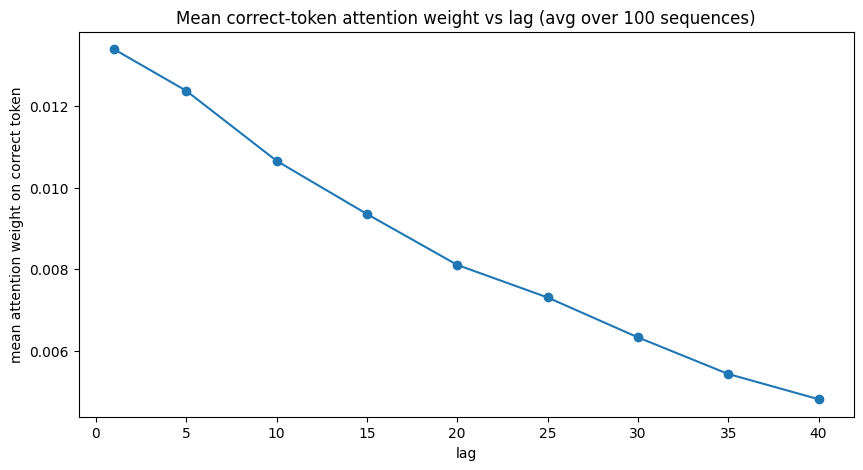

In [18]:
# inspect attention using the new range model
with torch.no_grad():
    logits1, A1_range = model2_range(xs1)
    logits20, A20_range = model2_range(xs20)

xs35, ys35, r1_35, r2_35 = generate_example(lag=35)
with torch.no_grad():
    _, A35_range = model2_range(xs35)

correct1 = inspect_attention(A1_range, lag=1, verbose=False)
correct20 = inspect_attention(A20_range, lag=20, verbose=False)
correct35 = inspect_attention(A35_range, lag=35, verbose=False)

def plot_mean_correct_weight_vs_lag(model, lag_list=(1, 5, 10, 15, 20, 25, 30, 35, 40),
                                     probe_start=80, probe_len=20, num_examples_per_lag=100):
    means_outer = []
    stds_outer = []
    for lag in lag_list:
        means_inner = []
        for i in range(num_examples_per_lag):
            xs_ex, ys_ex, r1_ex, r2_ex = generate_example(lag=lag)
            with torch.no_grad():
                _, A_ex = model(xs_ex)
            correct_weights = inspect_attention(A_ex, lag=lag, probe_start=probe_start, probe_len=probe_len, verbose=False)
            vals = [v for t, v in correct_weights]
            if vals:
                means_inner.append(np.mean(vals))

        means_outer.append(np.mean(means_inner) if means_inner else np.nan)
        stds_outer.append(np.std(means_inner) if means_inner else np.nan)

    means_outer = np.array(means_outer)
    stds_outer = np.array(stds_outer)

    plt.figure(figsize=(10, 5))
    plt.plot(lag_list, means_outer, marker='o')
    plt.xlabel('lag')
    plt.ylabel('mean attention weight on correct token')
    plt.title(f'Mean correct-token attention weight vs lag (avg over {num_examples_per_lag} sequences)')
    plt.show()

    return lag_list, means_outer, stds_outer



lag_list, means, stds = plot_mean_correct_weight_vs_lag(model2_range, num_examples_per_lag=100)







- The mean attention weight on the correct token clearly seems to drop with lag according to this graph
    - this could (as was my assumption) possibly align with the drop in performance with increasing lag observed earlier.
- However, due to the use of softmax, the number of valid (unmasked) keys grows - so as t increases, the sum of weightings across the row tends to naturally decrease, making it hard to interpret the measurements above.

##### Comparing to the baseline lag (if attention is equally distributed among keys)
To resolve the ambiguity above, I need a way to tell lag tracking apart from attention that's just generically spread.
- The "baseline" attention is the attention of a query to a key if all of its attention is spread equally among the possible keys it can attend to.
- The function avg_correct_attention_ratio() is meant to compare the weight on the "correct" token to this "expected" weight. 
- To adjust for the different scales of attention weightings between rows (due to softmax) we will use the metric correct_token_weight / baseline_weight

lag=  1: mean correct/chance ratio = 2.442
lag=  5: mean correct/chance ratio = 2.323
lag= 10: mean correct/chance ratio = 2.264
lag= 15: mean correct/chance ratio = 2.268
lag= 20: mean correct/chance ratio = 2.111
lag= 25: mean correct/chance ratio = 2.052
lag= 30: mean correct/chance ratio = 1.937
lag= 35: mean correct/chance ratio = 1.915
lag= 40: mean correct/chance ratio = 1.812


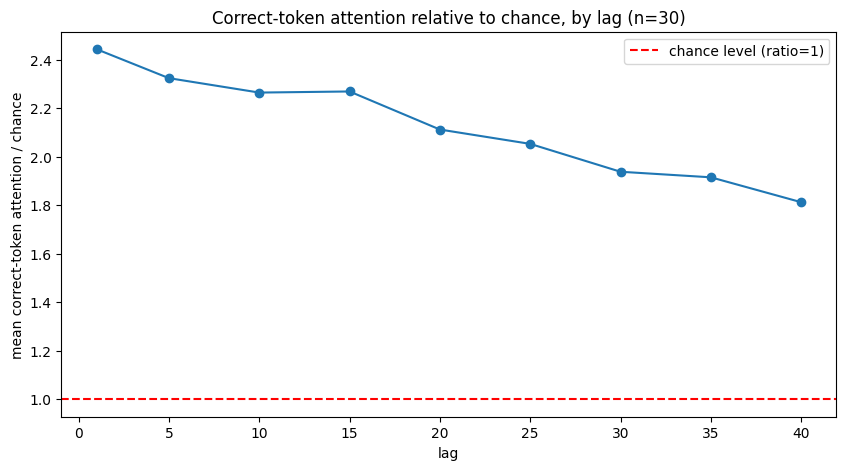

In [12]:
def uniform_baseline_matrix(xs_example):
    """Build the per-row uniform-attention baseline using same mask as the model."""
    time_of = xs_example[0, :, 2]
    N = time_of.shape[0]

    mask = (time_of.unsqueeze(1) < time_of.unsqueeze(0)).to(device)  

    scores = torch.zeros(N, N, device=device)
    scores = scores.masked_fill(mask, float('-inf'))
    baseline_A = torch.softmax(scores, dim=-1)

    return baseline_A

xs_dummy, ys_dummy, r1_dummy, r2_dummy = generate_example(lag=1)
baseline_A = uniform_baseline_matrix(xs_dummy)


def avg_correct_attention_ratio(model, lag, n_examples=30, buffer=100, T_train=180):
    start_t = lag + buffer
    end_t = T_train
    ratios = []

    for _ in range(n_examples):
        x1, y1, r1, r2 = generate_example(lag=lag)
        with torch.no_grad():
            _, A = model(x1)
        A_np = A[0].cpu().numpy()
        N = A_np.shape[0]

        for t in range(start_t, end_t):
            query_token = 2*t + 1
            correct_time = t - lag + 1
            if correct_time < 0:
                continue
            correct_j = 2 * correct_time

            actual = A_np[query_token, correct_j]
            n_valid = 2 * (t + 1)
            uniform = 1.0 / n_valid
            ratios.append(actual / uniform)

    return np.mean(ratios) if ratios else np.nan


def compare_ratio_across_lags(model, lag_list=(1, 5, 10, 15, 20, 25, 30, 35, 40), n_examples=30, buffer=100, T_train=180):
    results = {}
    for lag in lag_list:
        ratio = avg_correct_attention_ratio(model, lag, n_examples=n_examples, buffer=buffer, T_train=T_train)
        results[lag] = ratio
        print(f"lag={lag:3d}: mean correct/chance ratio = {ratio:.3f}")

    plt.figure(figsize=(10, 5))
    plt.plot(list(results.keys()), list(results.values()), marker='o')
    plt.axhline(1.0, color='red', linestyle='--', label='chance level (ratio=1)')
    plt.xlabel('lag')
    plt.ylabel('mean correct-token attention / chance')
    plt.title(f'Correct-token attention relative to chance, by lag (n={n_examples})')
    plt.legend()
    plt.show()
    return results


results = compare_ratio_across_lags(model2_range)

- According to this baseline comparison measurement, a similar trend occurs. 
- The correct token weighting (this time relative to the baseline) tends to decrease still with lag.


- I am not sure how robust this attention weighting interpretation is, because it's indirect. But out of curiosity, I would like to see how the attention distribution differs with different lags
- I will do this by taking all cells at a certain timestep, and where the driven/dependent asset is the query against, and the driver is the key. (I chose t=150, because it's at a late point where the model "has time" within the sequence to recognize the dependency) 


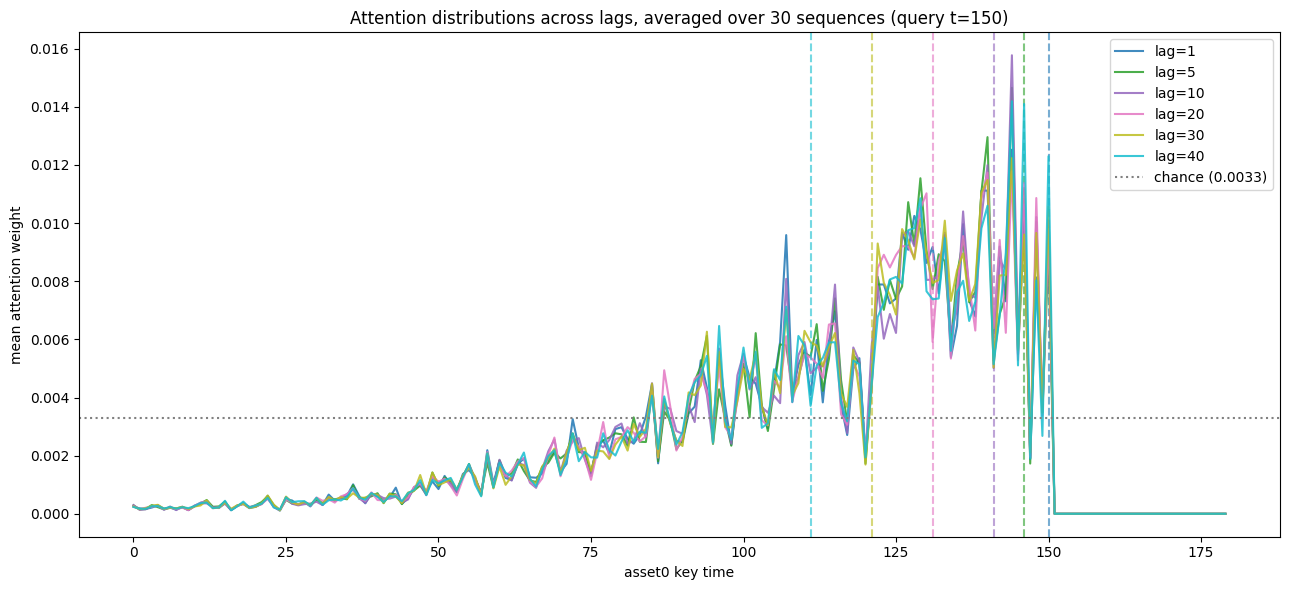

In [13]:
def plot_avg_attention_rows_multi_lag(model, lag_list=(1, 5, 10, 20, 30, 40),
                                       query_t=150, n_examples=30, T_train=180):
    """
    Overlay attention distributions for multiple lags, averaged over n_examples
    sequences per lag. Each lag's correct position is marked in matching color.
    """
    fig, ax = plt.subplots(figsize=(13, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(lag_list)))

    query_token = 2 * query_t + 1
    n_asset0 = (2 * T_train) // 2  # number of asset0 keys = T_train

    for color, lag in zip(colors, lag_list):
        correct_time = query_t - lag + 1

        acc = np.zeros(n_asset0)
        count = 0
        for _ in range(n_examples):
            x1, y1, r1, r2 = generate_example(lag=lag)
            with torch.no_grad():
                _, A = model(x1)
            A_np = A[0].cpu().numpy()
            acc += A_np[query_token, 0::2]  # asset0 keys
            count += 1
        avg_weights = acc / count

        key_times = np.arange(n_asset0)
        ax.plot(key_times, avg_weights, color=color, alpha=0.85, label=f'lag={lag}')
        ax.axvline(correct_time, color=color, linestyle='--', alpha=0.6)

    n_valid = 2 * (query_t + 1)
    ax.axhline(1.0 / n_valid, color='gray', linestyle=':', label=f'chance ({1.0/n_valid:.4f})')

    ax.set_xlabel('asset0 key time')
    ax.set_ylabel('mean attention weight')
    ax.set_title(f'Attention distributions across lags, averaged over {n_examples} sequences (query t={query_t})')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_avg_attention_rows_multi_lag(model2_range, lag_list=(1, 5, 10, 20, 30, 40),query_t=150, n_examples=30)

## Findings: one-head model 

- The model's attention distributions across different lags are essentially identical, regardless of where the true correct position falls. 

- This suggests attention may not the mechanism by which this model achieves any 
  predictive signal it has. Two possibilities are (1) lag-sensitivity could 
  live elsewhere in the network (e.g. the OV circuit) or (2) the model simply 
  hasn't learned to detect lag at all, and whatever modest performance it has comes 
  from the recency-weighted attention happening to correlate with the true signal on 
  average, rather than genuine lag-specific retrieval. 
  - (2) seems more likely given that the model barely achieved half the theoretical correlation, and the correlation with the lagged variable dropped with increasing lag. 

- the model could be learning to settle on more recent tokens, which could account for the earlier dominance of lag-1 performance compared to other lag values.

# Trying another model
- a one head model could be ill-equipped to learn the task at hand.
- While the task seems simple on the surface, it seems like it may be complicated under the surface for a small model. The model has to not only determine a correlation (and in the rho < 1 cases, the process is hindered by noise) but also learn the delay, and then route the result back to the current timestep of the other asset.
- Therefore I will try to add another layer here.
- Relative positional encodings are also more appropriate given the task, which inherently requires some indication of relative position

In [15]:
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class PricePredictorRoPE2L3H(nn.Module):
    """2 layers, 3 heads per layer, RoPE, larger d_model"""
    def __init__(self, num_assets, d_model=64, d_head=32):
        super().__init__()
        self.asset_embedding = nn.Embedding(num_assets, d_model)
        self.W_r = nn.Linear(1, d_model)

        k = torch.arange(0, d_head // 2).float()
        self.register_buffer('theta', 1.0 / (10000 ** (2 * k / d_head)))

        def make_head_params():
            return (
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),
                nn.Parameter(torch.randn(d_model, d_head) * 0.02),
                nn.Parameter(torch.randn(d_head, d_model) * 0.02),
            )

        self.W_Q1a, self.W_K1a, self.W_V1a, self.W_O1a = make_head_params()
        self.W_Q1b, self.W_K1b, self.W_V1b, self.W_O1b = make_head_params()
        self.W_Q1c, self.W_K1c, self.W_V1c, self.W_O1c = make_head_params()

        self.W_Q2a, self.W_K2a, self.W_V2a, self.W_O2a = make_head_params()
        self.W_Q2b, self.W_K2b, self.W_V2b, self.W_O2b = make_head_params()
        self.W_Q2c, self.W_K2c, self.W_V2c, self.W_O2c = make_head_params()

        self.W_U = nn.Linear(d_model, 1, bias=True)
        self.d_head = d_head

    def apply_rope(self, x, time_ids):
        B, N, d = x.shape
        half = d // 2
        angles = time_ids.float().unsqueeze(-1) * self.theta
        cos_a, sin_a = torch.cos(angles), torch.sin(angles)
        x1, x2 = x[..., :half], x[..., half:]
        return torch.cat([x1*cos_a - x2*sin_a, x1*sin_a + x2*cos_a], dim=-1)

    def forward(self, x):
        returns, asset_ids, time_ids = x[:,:,0], x[:,:,1].long(), x[:,:,2].long()
        r = self.W_r(returns.unsqueeze(-1))
        a = self.asset_embedding(asset_ids)
        x_0 = r + a

        time_of = x[:, :, 2]
        mask = (time_of.unsqueeze(2) < time_of.unsqueeze(1)).to(x.device)

        def head(xin, WQ, WK, WV, WO):
            Q = self.apply_rope(xin @ WQ, time_ids)
            K = self.apply_rope(xin @ WK, time_ids)
            scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_head)
            scores = scores.masked_fill(mask, float('-inf'))
            A = F.softmax(scores, dim=-1)
            return A, (A @ (xin @ WV)) @ WO

        A1a, d1a = head(x_0, self.W_Q1a, self.W_K1a, self.W_V1a, self.W_O1a)
        A1b, d1b = head(x_0, self.W_Q1b, self.W_K1b, self.W_V1b, self.W_O1b)
        A1c, d1c = head(x_0, self.W_Q1c, self.W_K1c, self.W_V1c, self.W_O1c)
        x_1 = x_0 + d1a + d1b + d1c

        A2a, d2a = head(x_1, self.W_Q2a, self.W_K2a, self.W_V2a, self.W_O2a)
        A2b, d2b = head(x_1, self.W_Q2b, self.W_K2b, self.W_V2b, self.W_O2b)
        A2c, d2c = head(x_1, self.W_Q2c, self.W_K2c, self.W_V2c, self.W_O2c)
        x_2 = x_1 + d2a + d2b + d2c

        logits = self.W_U(x_2)
        return logits, (A1a, A1b, A1c, A2a, A2b, A2c)


# --- data ---
xs_rho1_test, ys_rho1_test, lags_rho1_test, lag_to_idx_rho1_test = make_dataset_range(
    num_examples=1000, T=180, rho=1.0, lag_range=(1, 40), seed_offset=70000)
xs_rho1_test_dev = xs_rho1_test.to(device)
ys_rho1_test_dev = ys_rho1_test.to(device)

# --- load the verified-strong checkpoint, NO training ---
model_rope_2l3h_rho1 = PricePredictorRoPE2L3H(num_assets=2).to(device)
model_rope_2l3h_rho1.load_state_dict(torch.load('model_rope_2l3h_rho1_trained.pt', map_location=device))
model_rope_2l3h_rho1.eval()

evaluate_by_lag_range(model_rope_2l3h_rho1, xs_rho1_test_dev, ys_rho1_test_dev, lags_rho1_test, T=180, lag_list=(1, 10, 20, 30, 40))

torch.Size([1000, 360, 3]) torch.Size([1000, 360, 3]) torch.Size([1000])
lag=  1: r_target=0.7829, r_driver=0.7829, R²=0.6081
lag= 10: r_target=0.7611, r_driver=0.7611, R²=0.5740
lag= 20: r_target=0.7465, r_driver=0.7465, R²=0.5510
lag= 30: r_target=0.7990, r_driver=0.7990, R²=0.6339
lag= 40: r_target=0.6898, r_driver=0.6898, R²=0.4630


{1: {'r_target': 0.7829499568053115,
  'r_driver': 0.7829499568053115,
  'R2': 0.608063197905338},
 10: {'r_target': 0.761074280540232,
  'r_driver': 0.761074280540232,
  'R2': 0.5740179091507251},
 20: {'r_target': 0.7465165193736889,
  'r_driver': 0.7465165193736889,
  'R2': 0.5510015776974981},
 30: {'r_target': 0.7989513888954001,
  'r_driver': 0.7989513888954001,
  'R2': 0.6338649343952867},
 40: {'r_target': 0.6898430550237445,
  'r_driver': 0.6898430550237445,
  'R2': 0.46302008087436997}}

OOD Performance Check of RoPE 3-layer model
- First with 1.0
- Then with 0.9 (To show whether the randomness has a catastrophic effect on this new model trained on deterministic corr.)

In [17]:
xs_rho1_ood, ys_rho1_ood, lags_rho1_ood, lag_to_idx_rho1_ood = make_dataset_range(num_examples=1000, T=180, rho=1.0, lag_range=(41, 80), seed_offset=85000)

xs_rho1_ood_dev = xs_rho1_ood.to(device)
ys_rho1_ood_dev = ys_rho1_ood.to(device)

evaluate_by_lag_range(model_rope_2l3h_rho1, xs_rho1_ood_dev, ys_rho1_ood_dev, lags_rho1_ood, T=180, lag_list=(45, 55, 65, 75))

torch.Size([1000, 360, 3]) torch.Size([1000, 360, 3]) torch.Size([1000])
lag= 45: r_target=0.2330, r_driver=0.2330, R²=-0.2423
lag= 55: r_target=0.0156, r_driver=0.0156, R²=-0.5833
lag= 65: r_target=0.0199, r_driver=0.0199, R²=-0.6018
lag= 75: r_target=-0.0097, r_driver=-0.0097, R²=-0.6652


{45: {'r_target': 0.23295672004794618,
  'r_driver': 0.23295672004794618,
  'R2': -0.2422709806768184},
 55: {'r_target': 0.015624644981249583,
  'r_driver': 0.015624644981249583,
  'R2': -0.5832867291889958},
 65: {'r_target': 0.01989033271103821,
  'r_driver': 0.01989033271103821,
  'R2': -0.6017757283096592},
 75: {'r_target': -0.009656933979718164,
  'r_driver': -0.009656933979718164,
  'R2': -0.6651954354656469}}

In [18]:
# rho=0.9 held-out test set
xs_rho9_test, ys_rho9_test, lags_rho9_test, lag_to_idx_rho9_test = make_dataset_range(
    num_examples=1000, T=180, rho=0.9, lag_range=(1, 40), seed_offset=80000)

xs_rho9_test_dev = xs_rho9_test.to(device)
ys_rho9_test_dev = ys_rho9_test.to(device)

evaluate_by_lag_range(model_rope_2l3h_rho1, xs_rho9_test_dev, ys_rho9_test_dev, lags_rho9_test, T=180, lag_list=(1, 10, 20, 30, 40))

torch.Size([1000, 360, 3]) torch.Size([1000, 360, 3]) torch.Size([1000])
lag=  1: r_target=0.2967, r_driver=0.3231, R²=-0.1443
lag= 10: r_target=0.2744, r_driver=0.3036, R²=-0.1864
lag= 20: r_target=0.2227, r_driver=0.2433, R²=-0.2660
lag= 30: r_target=0.2725, r_driver=0.3003, R²=-0.1672
lag= 40: r_target=0.2023, r_driver=0.2264, R²=-0.2940


{1: {'r_target': 0.2966567483182407,
  'r_driver': 0.3231366757805501,
  'R2': -0.14431245205934928},
 10: {'r_target': 0.27443436260500764,
  'r_driver': 0.3035762382768051,
  'R2': -0.1864120464811465},
 20: {'r_target': 0.22267411194088033,
  'r_driver': 0.24330155456840696,
  'R2': -0.2660001193440986},
 30: {'r_target': 0.27247310635346345,
  'r_driver': 0.30033574815615793,
  'R2': -0.1672190839047123},
 40: {'r_target': 0.20232635531325854,
  'r_driver': 0.22640151850250778,
  'R2': -0.2939547050578446}}

In [19]:
# for apples-to-apples comparison - testing on data generated within training lag distribution, but independently from the other variable. 
xs_rho1_test, ys_rho1_test, lags_rho1_test, lag_to_idx_rho1_test = make_dataset_range(
    num_examples=1000, T=180, rho=1.0, lag_range=(1, 40), seed_offset=70000)

xs_rho1_test_dev = xs_rho1_test.to(device)
ys_rho1_test_dev = ys_rho1_test.to(device)
 
evaluate_by_lag_range(model_rope_2l3h_rho1, xs_rho1_test_dev, ys_rho1_test_dev, lags_rho1_test, T=180, lag_list=(1, 10, 20, 30, 40))

torch.Size([1000, 360, 3]) torch.Size([1000, 360, 3]) torch.Size([1000])
lag=  1: r_target=0.8078, r_driver=0.8078, R²=0.6496
lag= 10: r_target=0.7779, r_driver=0.7779, R²=0.6034
lag= 20: r_target=0.7645, r_driver=0.7645, R²=0.5815
lag= 30: r_target=0.7955, r_driver=0.7955, R²=0.6293
lag= 40: r_target=0.6607, r_driver=0.6607, R²=0.4227


{1: {'r_target': 0.8077592483582436,
  'r_driver': 0.8077592483582436,
  'R2': 0.6496067439585074},
 10: {'r_target': 0.7778982200379319,
  'r_driver': 0.7778982200379319,
  'R2': 0.6034341971182907},
 20: {'r_target': 0.7645052723492989,
  'r_driver': 0.7645052723492989,
  'R2': 0.5814837433442981},
 30: {'r_target': 0.7954867770920376,
  'r_driver': 0.7954867770920376,
  'R2': 0.6292950116351345},
 40: {'r_target': 0.6607411912642301,
  'r_driver': 0.6607411912642301,
  'R2': 0.42273228401766805}}

#### Notes on the performance of the 3-layer, RoPE model trained on 100% correlation (deterministic relationship)

- The model seems to be achieving some signal when tested within distribution in terms of the lags, that is, wthin the ranges of (1,40)
- However it's not perfect - the theoretical correlation suggests *r_driver* should be ~1, it's getting .7-.9
- Performance collapses drastically when:
1) OOD lags are introduced
2) The scenario is no longer deterministic (rho < 1), even with in-distribution lag


In [20]:
evaluate_by_lag_range(model_rope_2l3h_rho1, xs_rho1_test_dev, ys_rho1_test_dev, lags_rho1_test, T=180, lag_list=(1, 10, 20, 30, 40))

lag=  1: r_target=0.8078, r_driver=0.8078, R²=0.6496
lag= 10: r_target=0.7779, r_driver=0.7779, R²=0.6034
lag= 20: r_target=0.7645, r_driver=0.7645, R²=0.5815
lag= 30: r_target=0.7955, r_driver=0.7955, R²=0.6293
lag= 40: r_target=0.6607, r_driver=0.6607, R²=0.4227


{1: {'r_target': 0.8077592483582436,
  'r_driver': 0.8077592483582436,
  'R2': 0.6496067439585074},
 10: {'r_target': 0.7778982200379319,
  'r_driver': 0.7778982200379319,
  'R2': 0.6034341971182907},
 20: {'r_target': 0.7645052723492989,
  'r_driver': 0.7645052723492989,
  'R2': 0.5814837433442981},
 30: {'r_target': 0.7954867770920376,
  'r_driver': 0.7954867770920376,
  'R2': 0.6292950116351345},
 40: {'r_target': 0.6607411912642301,
  'r_driver': 0.6607411912642301,
  'R2': 0.42273228401766805}}

#### Failure mode interpretation
- Why is the model behaving this way?
- How is it detecting (or not detecting) lag?
- What is different about examples where it performs well versus examples where it performs poorly?

##### Test 1. Probing
- To try to isolate the lag, I will use a simple linear model on residual stream vectors. The flow is:
1) Run a forward pass of the model, but also extract both residual stream vectors per sequence (after layer 1, after layer 2), at a fixed query position.
2) Label the residual stream vectors with the true known lag from the sequence
3) Train a linear model (ridge regression, to keep the probe well-conditioned given 64 features vs 450 training examples) with the components of the residual stream vectors as features, and the lag labels as targets.
- Also need to use a balanced sample across lags, and will use a 75/25 train test split 
4) Also train another model after having shuffled the lag labels (for a baseline)
5) Evaluate both models' performance on examples once for each layer. 
    - If there's very high performance compared to the baseline model, the real model's representation of lag linealy correlates with features in the given layer. 

In [31]:
def forward_with_residuals(self, x):
    returns, asset_ids, time_ids = x[:,:,0], x[:,:,1].long(), x[:,:,2].long()
    r = self.W_r(returns.unsqueeze(-1))
    a = self.asset_embedding(asset_ids)
    x_0 = r + a

    time_of = x[:, :, 2]
    mask = (time_of.unsqueeze(2) < time_of.unsqueeze(1)).to(x.device)

    def head(xin, WQ, WK, WV, WO):
        Q = self.apply_rope(xin @ WQ, time_ids)
        K = self.apply_rope(xin @ WK, time_ids)
        scores = Q @ K.transpose(-2,-1) / math.sqrt(self.d_head)
        scores = scores.masked_fill(mask, float('-inf'))
        A = F.softmax(scores, dim=-1)
        return A, (A @ (xin @ WV)) @ WO

    A1a, d1a = head(x_0, self.W_Q1a, self.W_K1a, self.W_V1a, self.W_O1a)
    A1b, d1b = head(x_0, self.W_Q1b, self.W_K1b, self.W_V1b, self.W_O1b)
    A1c, d1c = head(x_0, self.W_Q1c, self.W_K1c, self.W_V1c, self.W_O1c)
    x_1 = x_0 + d1a + d1b + d1c

    A2a, d2a = head(x_1, self.W_Q2a, self.W_K2a, self.W_V2a, self.W_O2a)
    A2b, d2b = head(x_1, self.W_Q2b, self.W_K2b, self.W_V2b, self.W_O2b)
    A2c, d2c = head(x_1, self.W_Q2c, self.W_K2c, self.W_V2c, self.W_O2c)
    x_2 = x_1 + d2a + d2b + d2c

    logits = self.W_U(x_2)
    return logits, (A1a, A1b, A1c, A2a, A2b, A2c), x_1, x_2 # also gonna return resid. stream

import types
model_rope_2l3h_rho1.forward_with_residuals = types.MethodType(forward_with_residuals, model_rope_2l3h_rho1)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def run_lag_probe_full(model, layer='x1', query_t=150, n_per_lag=15,
                        alpha=1.0, n_shuffles=5, lag_range=(1, 40), rho=1.0):
    X, y = [], []
    for lag in range(lag_range[0], lag_range[1] + 1):
        for _ in range(n_per_lag):
            x1_input, y1, r1, r2 = generate_example(lag=lag, rho=rho)  # FIXED: explicit rho
            with torch.no_grad():
                _, _, x_1, x_2 = model.forward_with_residuals(x1_input)
            vec = (x_1 if layer == 'x1' else x_2)[0, 2*query_t + 1].cpu().numpy()
            X.append(vec)
            y.append(lag)

    X = np.array(X)
    y = np.array(y)
    print(f"probe dataset: {X.shape[0]} examples, {X.shape[1]} dims, "
          f"{len(np.unique(y))} distinct lags, {n_per_lag} per lag")

    norms = np.linalg.norm(X, axis=1)
    norm_corr = np.corrcoef(norms, y)[0, 1]
    print(f"correlation between residual-vector NORM and true lag: {norm_corr:.4f}  "
          f"({'low — likely a directional signal' if abs(norm_corr) < 0.3 else 'NOTABLE — check magnitude confound'})")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=0, stratify=y)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    # --- fit real probe, evaluate on held-out test set (FIXED solver, deterministic) ---
    probe = Ridge(alpha=alpha, solver='svd').fit(X_train_s, y_train)
    real_r2 = probe.score(X_test_s, y_test)

    # --- shuffled-label baseline (SAME fixed solver, for a fair comparison) ---
    shuffle_r2s = []
    for s in range(n_shuffles):
        rng = np.random.RandomState(s)
        y_train_shuf = rng.permutation(y_train)
        probe_shuf = Ridge(alpha=alpha, solver='svd').fit(X_train_s, y_train_shuf)
        shuffle_r2s.append(probe_shuf.score(X_test_s, y_test))

    print(f"\nlayer={layer}, query_t={query_t}")
    print(f"  REAL probe test R^2:      {real_r2:.4f}")
    print(f"  shuffled-label baseline:  mean={np.mean(shuffle_r2s):.4f}  "
          f"(range {min(shuffle_r2s):.4f} to {max(shuffle_r2s):.4f})")
    print(f"  signal above baseline:    {real_r2 - np.mean(shuffle_r2s):.4f}")

    w = probe.coef_
    order = np.argsort(np.abs(w))[::-1]
    print(f"\n  top 10 dims by |coefficient| (most predictive of lag, on standardized scale):")
    for i in order[:10]:
        print(f"    dim {i:2d}: coef = {w[i]:+.4f}")

    direction = w / np.linalg.norm(w)
    X_test_proj = X_test_s @ direction
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, X_test_proj, alpha=0.4, s=18)
    plt.xlabel('true lag')
    plt.ylabel('projection onto probe direction')
    plt.title(f'Lag axis check — layer={layer}, query_t={query_t}')
    plt.tight_layout()
    plt.show()

    return {
        'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test,
        'scaler': scaler, 'probe': probe, 'real_r2': real_r2,
        'shuffle_r2s': shuffle_r2s, 'norm_corr': norm_corr, 'weights': w,
    }


results_x1 = run_lag_probe_full(model_rope_2l3h_rho1, layer='x1', query_t=150)
results_x2 = run_lag_probe_full(model_rope_2l3h_rho1, layer='x2', query_t=150)

##### Moving to MLP layer
- Realizing the complexity of the task (i.e. the model has to not only find correlation, but at the right lag, and also act on that lag so that it informs the next timestep prediction) the model may require more nuanced computation than just routing in its heads. 
- I dont think that the hard part of this task is the final prediction (once lag is known), since that could involve something like a simple routing
- Attention can already route back to specific elements in the timeseries, but this still leaves the challenge of identifying the right lag.
- By acting on the residual space, the MLP may be able to aggregate the residual stream vectors in a more nuanced way that allows for lag recognition
- for example, one possibility could be that attention heads gather specific similarity/relationships to the current token, and then an MLP can transform the result into some representation of lag.
- Therefore I will train and evaluate an MLP layer.
- To determine the effect of randomness on the model's capability, I will train two versions: one on a deterministic relationship (where there is no noise, and the time series is simply shifted) and one with some noise (rho = 0.9)

In [23]:
class PricePredictorMLP(nn.Module):
    def __init__(self, num_assets=2, d_model=128, d_head=32, mlp_mult=4):
        super().__init__()
        self.asset_embedding = nn.Embedding(num_assets, d_model)
        self.W_r = nn.Linear(1, d_model)
        k = torch.arange(0, d_head // 2).float()
        self.register_buffer('theta', 1.0 / (10000 ** (2 * k / d_head)))

        self.W_Q1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O1a = nn.Parameter(torch.randn(d_head, d_model) * 0.02)
        self.W_Q1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O1b = nn.Parameter(torch.randn(d_head, d_model) * 0.02)

        self.W_Q2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O2a = nn.Parameter(torch.randn(d_head, d_model) * 0.02)
        self.W_Q2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O2b = nn.Parameter(torch.randn(d_head, d_model) * 0.02)

        self.ln1_attn = nn.LayerNorm(d_model)
        self.ln1_mlp  = nn.LayerNorm(d_model)
        self.ln2_attn = nn.LayerNorm(d_model)
        self.ln2_mlp  = nn.LayerNorm(d_model)
        self.ln_final = nn.LayerNorm(d_model)

        self.mlp1 = nn.Sequential(nn.Linear(d_model, mlp_mult*d_model), nn.GELU(), nn.Linear(mlp_mult*d_model, d_model))
        self.mlp2 = nn.Sequential(nn.Linear(d_model, mlp_mult*d_model), nn.GELU(), nn.Linear(mlp_mult*d_model, d_model))

        self.W_U = nn.Linear(d_model, 1, bias=True)

    def forward(self, x):
        returns   = x[:, :, 0]
        asset_ids = x[:, :, 1].long()
        time_ids  = x[:, :, 2].long()

        r = self.W_r(returns.unsqueeze(-1))
        a = self.asset_embedding(asset_ids)
        x_0 = r + a

        time_of  = x[:, :, 2]
        causal_mask = (time_of.unsqueeze(2) < time_of.unsqueeze(1)).to(x.device)

        angles = time_ids.float().unsqueeze(-1) * self.theta
        cos_angles = torch.cos(angles)
        sin_angles = torch.sin(angles)

        def apply_rope(Q, K):
            B, N, d = Q.shape
            half = d // 2
            R = torch.zeros(B, N, d, d, device=Q.device)
            for k_idx in range(half):
                R[:, :, k_idx,        k_idx]        =  cos_angles[:, :, k_idx]
                R[:, :, k_idx,        k_idx + half] = -sin_angles[:, :, k_idx]
                R[:, :, k_idx + half, k_idx]        =  sin_angles[:, :, k_idx]
                R[:, :, k_idx + half, k_idx + half] =  cos_angles[:, :, k_idx]
            Q_rot = (R @ Q.unsqueeze(-1)).squeeze(-1)
            K_rot = (R @ K.unsqueeze(-1)).squeeze(-1)
            return Q_rot, K_rot

        def head(xin, WQ, WK, WV, WO):
            Q = xin @ WQ
            K = xin @ WK
            Q, K = apply_rope(Q, K)
            scores = Q @ K.transpose(-2, -1) / math.sqrt(WQ.shape[1])
            scores = scores.masked_fill(causal_mask, float('-inf'))
            A = F.softmax(scores, dim=-1)
            return A, A @ xin @ WV @ WO

        h = self.ln1_attn(x_0)
        A1a, d1a = head(h, self.W_Q1a, self.W_K1a, self.W_V1a, self.W_O1a)
        A1b, d1b = head(h, self.W_Q1b, self.W_K1b, self.W_V1b, self.W_O1b)
        x_0 = x_0 + d1a + d1b
        x_0 = x_0 + self.mlp1(self.ln1_mlp(x_0))

        h = self.ln2_attn(x_0)
        A2a, d2a = head(h, self.W_Q2a, self.W_K2a, self.W_V2a, self.W_O2a)
        A2b, d2b = head(h, self.W_Q2b, self.W_K2b, self.W_V2b, self.W_O2b)
        x_0 = x_0 + d2a + d2b
        x_0 = x_0 + self.mlp2(self.ln2_mlp(x_0))

        logits = self.W_U(self.ln_final(x_0))
        return logits, (A1a, A1b, A2a, A2b)

In [ ]:
def generate_batch(batch_size=32, T=180, rho=1.0, lag_range=(1, 40)):
    """On-the-fly batch generator: same DGP and interleaving as make_dataset_range,
    but builds one batch per call instead of a whole dataset up front."""
    xs_list, ys_list, lags_list = [], [], []
    for i in range(batch_size):
        lag_i = random.randint(lag_range[0], lag_range[1])
        lags_list.append(lag_i)

        r1, r2 = simulate_factor_model_varlag(rho=rho, lag=lag_i, T=T+1, seed=None)
        r1_x, r1_y = r1[:-1], r1[1:]
        r2_x, r2_y = r2[:-1], r2[1:]
        times_x = list(range(T))

        interleaved_x, interleaved_y = [], []
        for t1, t2 in zip(zip(r1_x, [0]*T, times_x), zip(r2_x, [1]*T, times_x)):
            interleaved_x.append(t1)
            interleaved_x.append(t2)
        for t1, t2 in zip(zip(r1_y, [0]*T, times_x), zip(r2_y, [1]*T, times_x)):
            interleaved_y.append(t1)
            interleaved_y.append(t2)

        xs_list.append(interleaved_x)
        ys_list.append(interleaved_y)

    xb = torch.tensor(xs_list, dtype=torch.float32).to(device)
    yb = torch.tensor(ys_list, dtype=torch.float32).to(device)
    lags_batch = torch.tensor(lags_list, dtype=torch.long).to(device)
    return xb, yb, lags_batch

class PricePredictorMLP(nn.Module):
    def __init__(self, num_assets=2, d_model=128, d_head=32, mlp_mult=4):
        super().__init__()
        self.asset_embedding = nn.Embedding(num_assets, d_model)
        self.W_r = nn.Linear(1, d_model)
        k = torch.arange(0, d_head // 2).float()
        self.register_buffer('theta', 1.0 / (10000 ** (2 * k / d_head)))

        self.W_Q1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V1a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O1a = nn.Parameter(torch.randn(d_head, d_model) * 0.02)
        self.W_Q1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V1b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O1b = nn.Parameter(torch.randn(d_head, d_model) * 0.02)

        self.W_Q2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V2a = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O2a = nn.Parameter(torch.randn(d_head, d_model) * 0.02)
        self.W_Q2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_K2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_V2b = nn.Parameter(torch.randn(d_model, d_head) * 0.02)
        self.W_O2b = nn.Parameter(torch.randn(d_head, d_model) * 0.02)

        self.ln1_attn = nn.LayerNorm(d_model)
        self.ln1_mlp  = nn.LayerNorm(d_model)
        self.ln2_attn = nn.LayerNorm(d_model)
        self.ln2_mlp  = nn.LayerNorm(d_model)
        self.ln_final = nn.LayerNorm(d_model)

        self.mlp1 = nn.Sequential(nn.Linear(d_model, mlp_mult*d_model), nn.GELU(), nn.Linear(mlp_mult*d_model, d_model))
        self.mlp2 = nn.Sequential(nn.Linear(d_model, mlp_mult*d_model), nn.GELU(), nn.Linear(mlp_mult*d_model, d_model))

        self.W_U = nn.Linear(d_model, 1, bias=True)

    def forward(self, x):
        returns   = x[:, :, 0]
        asset_ids = x[:, :, 1].long()
        time_ids  = x[:, :, 2].long()

        r = self.W_r(returns.unsqueeze(-1))
        a = self.asset_embedding(asset_ids)
        x_0 = r + a

        time_of  = x[:, :, 2]
        causal_mask = (time_of.unsqueeze(2) < time_of.unsqueeze(1)).to(x.device)

        angles = time_ids.float().unsqueeze(-1) * self.theta
        cos_angles = torch.cos(angles)
        sin_angles = torch.sin(angles)

        def apply_rope(Q, K):
            B, N, d = Q.shape
            half = d // 2
            R = torch.zeros(B, N, d, d, device=Q.device)
            for k_idx in range(half):
                R[:, :, k_idx,        k_idx]        =  cos_angles[:, :, k_idx]
                R[:, :, k_idx,        k_idx + half] = -sin_angles[:, :, k_idx]
                R[:, :, k_idx + half, k_idx]        =  sin_angles[:, :, k_idx]
                R[:, :, k_idx + half, k_idx + half] =  cos_angles[:, :, k_idx]
            Q_rot = (R @ Q.unsqueeze(-1)).squeeze(-1)
            K_rot = (R @ K.unsqueeze(-1)).squeeze(-1)
            return Q_rot, K_rot

        def head(xin, WQ, WK, WV, WO):
            Q = xin @ WQ
            K = xin @ WK
            Q, K = apply_rope(Q, K)
            scores = Q @ K.transpose(-2, -1) / math.sqrt(WQ.shape[1])
            scores = scores.masked_fill(causal_mask, float('-inf'))
            A = F.softmax(scores, dim=-1)
            return A, A @ xin @ WV @ WO

        h = self.ln1_attn(x_0)
        A1a, d1a = head(h, self.W_Q1a, self.W_K1a, self.W_V1a, self.W_O1a)
        A1b, d1b = head(h, self.W_Q1b, self.W_K1b, self.W_V1b, self.W_O1b)
        x_0 = x_0 + d1a + d1b
        x_0 = x_0 + self.mlp1(self.ln1_mlp(x_0))

        h = self.ln2_attn(x_0)
        A2a, d2a = head(h, self.W_Q2a, self.W_K2a, self.W_V2a, self.W_O2a)
        A2b, d2b = head(h, self.W_Q2b, self.W_K2b, self.W_V2b, self.W_O2b)
        x_0 = x_0 + d2a + d2b
        x_0 = x_0 + self.mlp2(self.ln2_mlp(x_0))

        logits = self.W_U(self.ln_final(x_0))
        return logits, (A1a, A1b, A2a, A2b)


def train_mlp(model, n_steps=300000, T=180, rho=1.0, lag_range=(1, 40), lr=1e-3, wd=0.03, tag="d128", ckpt_every=25000):
    model.train()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    for step in range(n_steps):
        xb, yb, lags_batch = generate_batch(batch_size=32, T=T, rho=rho, lag_range=lag_range)
        pred, _ = model(xb)
        N = pred.shape[1]
        token_times = torch.arange(N, device=device) // 2
        warmup_per_seq = (lags_batch + 10).float()
        asset_ids = xb[:, :, 1]
        is_asset1 = (asset_ids == 1)  # mask: only score the driven asset
        mask_loss = (token_times.unsqueeze(0) >= warmup_per_seq.unsqueeze(1)).float() * is_asset1.float()
        loss = ((pred.squeeze(-1) - yb[:, :, 0])**2 * mask_loss).sum()
        loss = loss / (mask_loss.sum() + 1e-8)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 5000 == 0:
            print(f"step {step}, loss {loss.item():.4f}")
        if step > 0 and step % ckpt_every == 0:
            torch.save(model.state_dict(), f'model_mlp_{tag}_step{step}.pt')
            print(f"checkpoint saved at step {step}")
    torch.save(model.state_dict(), f'model_mlp_{tag}_final.pt')


# ---- launch training ----
model_mlp3 = PricePredictorMLP(num_assets=2, d_model=128, d_head=32).to(device)
results_summary = {}
def train_models():
    for rho_val in [1.0, 0.9]:
        print(f"\n{'='*60}")
        print(f"TRAINING at rho={rho_val}")
        print(f"{'='*60}")

        model_mlp3 = PricePredictorMLP(num_assets=2, d_model=128, d_head=32).to(device)
        train_mlp(model_mlp3, n_steps=300000, T=180, rho=rho_val, lag_range=(1, 40),
                lr=1e-3, wd=0.03, tag=f"d128_rho{rho_val}")

        model_mlp3.eval()

        xs_id, ys_id, lags_id, _ = make_dataset_range(num_examples=1500, T=180, rho=rho_val,
                                                        lag_range=(1, 40), seed_offset=500000)
        xs_id_dev, ys_id_dev = xs_id.to(device), ys_id.to(device)

        xs_ood, ys_ood, lags_ood, _ = make_dataset_range(num_examples=1500, T=180, rho=rho_val,
                                                        lag_range=(45, 75), seed_offset=600000)
        xs_ood_dev, ys_ood_dev = xs_ood.to(device), ys_ood.to(device)

        print(f"\n=== IN-DISTRIBUTION (rho={rho_val}) ===")
        res_id = evaluate_by_lag_range(model_mlp3, xs_id_dev, ys_id_dev, lags_id.to(device),
                                        T=180, lag_list=(1, 5, 10, 20, 30, 40), buffer=0)

        print(f"\n=== OUT-OF-DISTRIBUTION (rho={rho_val}, lags 45-75) ===")
        res_ood = evaluate_by_lag_range(model_mlp3, xs_ood_dev, ys_ood_dev, lags_ood.to(device),
                                        T=180, lag_list=(45, 50, 55, 60, 70, 75), buffer=0)

        id_mean = np.mean([res_id[l]['r_driver'] for l in res_id])
        ood_mean = np.mean([res_ood[l]['r_driver'] for l in res_ood])
        print(f"\nmean r_driver  rho={rho_val}  in-dist={id_mean:.3f}   OOD={ood_mean:.3f}   gap={id_mean-ood_mean:.3f}")

        results_summary[rho_val] = {'id': id_mean, 'ood': ood_mean}

    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    for rho_val, r in results_summary.items():
        print(f"rho={rho_val}: in-dist={r['id']:.3f}, OOD={r['ood']:.3f}, gap={r['id']-r['ood']:.3f}")

train_models()

In [ ]:
def evaluate_checkpoint(checkpoint_path, rho=1.0, T=180,
                          id_lag_range=(1, 40), ood_lag_range=(45, 75),
                          n_examples=1500, id_lag_list=(1, 5, 10, 20, 30, 40),
                          ood_lag_list=(45, 50, 55, 60, 70, 75)):
    model = PricePredictorMLP(num_assets=2, d_model=128, d_head=32).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    xs_id, ys_id, lags_id, _ = make_dataset_range(
        num_examples=n_examples, T=T, rho=rho, lag_range=id_lag_range, seed_offset=500000)
    xs_id_dev, ys_id_dev = xs_id.to(device), ys_id.to(device)

    xs_ood, ys_ood, lags_ood, _ = make_dataset_range(
        num_examples=n_examples, T=T, rho=rho, lag_range=ood_lag_range, seed_offset=600000)
    xs_ood_dev, ys_ood_dev = xs_ood.to(device), ys_ood.to(device)

    print(f"Checkpoint: {checkpoint_path}")
    print(f"\n=== IN-DISTRIBUTION (rho={rho}, lags {id_lag_range}) ===")
    res_id = evaluate_by_lag_range(model, xs_id_dev, ys_id_dev, lags_id.to(device),
                                    T=T, lag_list=id_lag_list, buffer=0)

    print(f"\n=== OUT-OF-DISTRIBUTION (rho={rho}, lags {ood_lag_range}) ===")
    res_ood = evaluate_by_lag_range(model, xs_ood_dev, ys_ood_dev, lags_ood.to(device),
                                     T=T, lag_list=ood_lag_list, buffer=0)

    id_mean = np.mean([res_id[l]['r_driver'] for l in res_id])
    ood_mean = np.mean([res_ood[l]['r_driver'] for l in res_ood])

    print(f"\nmean r_driver  rho={rho}  in-dist={id_mean:.3f}   OOD={ood_mean:.3f}   gap={id_mean-ood_mean:.3f}")

    return {'res_id': res_id, 'res_ood': res_ood, 'id_mean': id_mean, 'ood_mean': ood_mean, 'model': model}


results_75k = evaluate_checkpoint('model_mlp_d128_rho1.0_step75000.pt', rho=1.0)
results_75k_rho09 = evaluate_checkpoint('model_mlp_d128_rho1.0_step75000.pt', rho=0.9)

torch.Size([1500, 360, 3]) torch.Size([1500, 360, 3]) torch.Size([1500])
torch.Size([1500, 360, 3]) torch.Size([1500, 360, 3]) torch.Size([1500])
Checkpoint: model_mlp_d128_rho1.0_step75000.pt

=== IN-DISTRIBUTION (rho=1.0, lags (1, 40)) ===
lag=  1: r_target=0.9754, r_driver=0.9754, R²=0.9495
lag=  5: r_target=0.9721, r_driver=0.9721, R²=0.9427
lag= 10: r_target=0.9774, r_driver=0.9774, R²=0.9531
lag= 20: r_target=0.9709, r_driver=0.9709, R²=0.9401
lag= 30: r_target=0.9660, r_driver=0.9660, R²=0.9309
lag= 40: r_target=0.9599, r_driver=0.9599, R²=0.9184

=== OUT-OF-DISTRIBUTION (rho=1.0, lags (45, 75)) ===
lag= 45: r_target=0.8973, r_driver=0.8973, R²=0.7951
lag= 50: r_target=0.8469, r_driver=0.8469, R²=0.6940
lag= 55: r_target=0.7826, r_driver=0.7826, R²=0.5667
lag= 60: r_target=0.7155, r_driver=0.7155, R²=0.4299
lag= 70: r_target=0.5980, r_driver=0.5980, R²=0.2028
lag= 75: r_target=0.5516, r_driver=0.5516, R²=0.1026

mean r_driver  rho=1.0  in-dist=0.970   OOD=0.732   gap=0.238
torch

In [ ]:
def oracle_predict_known_lag(xs, lags_t, T, lag_list=(1, 10, 20, 30, 40), n=200):
    """Cheats: directly uses the true lag (not inferring it) to predict.
    This gives the theoretical ceiling for comparison."""
    results = {}
    for target_lag in lag_list:
        pred_all, target_all = [], []
        indices = (lags_t == target_lag).nonzero(as_tuple=True)[0][:n]

        for idx in indices:
            xb = xs[idx]
            r1_values = xb[::2, 0].cpu().numpy()   # asset0 returns
            r2_values = xb[1::2, 0].cpu().numpy()  # asset1 returns (for reference only)

            for t in range(target_lag, T - 1):
                driver_idx = t - target_lag + 1
                if 0 <= driver_idx < T:
                    # oracle "prediction" = rho * true driver value (perfect knowledge of rho and lag)
                    pred_all.append(r1_values[driver_idx])  # raw driver, scaled by rho below
                    # true target is r2[t+1], which equals rho*driver + noise
                    target_all.append(r2_values[t+1] if t+1 < T else np.nan)

        pred_arr = np.array(pred_all)
        target_arr = np.array(target_all)
        valid = ~np.isnan(target_arr)
        pred_arr, target_arr = pred_arr[valid], target_arr[valid]

        r, _ = stats.pearsonr(pred_arr, target_arr)
        results[target_lag] = r
        print(f"lag={target_lag:3d}: oracle r={r:.4f}  (theoretical ceiling, since oracle just IS rho)")
    return results

oracle_predict_known_lag(xs_dev_range, lags_t_range, T=180, lag_list=(1,10,20,30,40))